<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/03_I_Do_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ I Do — XGBoost (Extreme Gradient Boosting)
### Máster de FP en Business Analytics e Inteligencia Artificial
**Módulo:** Data Analytics: Data Science, Machine Learning e Inteligencia Artificial  
**Profesores:** Daniel Toral García · Álvaro López

---

## 🎯 ¿Qué vamos a aprender hoy?

En este notebook el profesor va a demostrar **paso a paso** cómo construir un modelo de **XGBoost**.

**Problema de negocio:** Un banco quiere optimizar sus campañas de telemarketing. Llamar a todos los clientes es caro e ineficiente. Quieren un modelo que, a partir del perfil del cliente y el historial de contactos, prediga si ese cliente **suscribirá o no un depósito a plazo fijo**. Así, los comerciales solo llaman a los clientes con mayor probabilidad de convertir.

**Dataset:** Simulación realista de una campaña bancaria (estructura basada en Bank Marketing UCI)  
- 10.000 contactos de telemarketing  
- 18 variables: edad, profesión, estado civil, tipo de contacto, indicadores macroeconómicos...  
- Target: ¿Suscribió el depósito a plazo? Sí (1) / No (0)

---

## 📋 Índice
1. Instalación e imports
2. Generación del dataset
3. Exploración de los datos
4. Preparación: encoding de variables categóricas
5. Random Forest vs XGBoost — ¿cuál es la diferencia clave?
6. Entrenamiento del modelo XGBoost
7. Early Stopping — parar en el momento justo
8. Evaluación: Accuracy, AUC-ROC, Matriz de Confusión
9. Feature Importance y explicabilidad
10. Comparativa directa: Random Forest vs XGBoost
11. Conclusiones de negocio

---
## 📦 1. Instalación e Imports

XGBoost viene preinstalado en Google Colab. Si trabajáis en local: `pip install xgboost`.

In [1]:
# ── Manipulación de datos ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ───────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder         # Para convertir texto → número
from sklearn.ensemble import RandomForestClassifier    # Para la comparativa final
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,      # Nueva métrica: AUC-ROC, muy usada en marketing/churn
    RocCurveDisplay
)

# ── XGBoost ────────────────────────────────────────────────────────────────
import xgboost as xgb
from xgboost import XGBClassifier   # Interfaz estilo scikit-learn

# ── Configuración visual ───────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 25)

print(f'✅ Librerías cargadas | XGBoost versión: {xgb.__version__}')

✅ Librerías cargadas | XGBoost versión: 3.2.0


---
## 🏦 2. Generación del Dataset

Creamos un dataset sintético que reproduce fielmente la estructura y distribuciones del **Bank Marketing Dataset** (UCI). La ventaja: funciona sin conexión a internet, es 100% reproducible y podemos controlar exactamente qué variables influyen en el target.

> 💡 En proyectos reales los datos vendrían del CRM del banco. Aquí simulamos ese escenario.

In [2]:
np.random.seed(42)   # Fijamos la semilla → todos obtendremos exactamente el mismo dataset
n = 10_000           # 10.000 contactos de telemarketing

# ── Variables categóricas ─────────────────────────────────────────────────
jobs     = ['admin.','blue-collar','technician','services','management',
            'retired','student','self-employed','unemployed','entrepreneur']
job_p    = [0.25, 0.22, 0.17, 0.10, 0.07, 0.05, 0.04, 0.04, 0.03, 0.03]
educats  = ['university.degree','high.school','basic.9y','professional.course','basic.6y','unknown']
months   = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

age      = np.random.normal(40, 11, n).clip(18, 75).astype(int)
job      = np.random.choice(jobs, n, p=job_p)
marital  = np.random.choice(['married','single','divorced'], n, p=[0.61, 0.28, 0.11])
education= np.random.choice(educats, n, p=[0.30, 0.23, 0.15, 0.13, 0.09, 0.10])
default  = np.random.choice(['no','yes','unknown'], n, p=[0.79, 0.01, 0.20])
housing  = np.random.choice(['yes','no','unknown'], n, p=[0.52, 0.45, 0.03])
loan     = np.random.choice(['no','yes','unknown'], n, p=[0.83, 0.16, 0.01])
contact  = np.random.choice(['cellular','telephone'], n, p=[0.64, 0.36])
month    = np.random.choice(months, n,
           p=[0.01, 0.05, 0.33, 0.06, 0.07, 0.06, 0.05, 0.07, 0.21, 0.09])

# ── Variables numéricas ────────────────────────────────────────────────────
campaign = np.random.poisson(2.5, n).clip(1, 15)           # Nº de contactos en esta campaña
pdays    = np.where(np.random.rand(n) < 0.85, 999,         # 999 = no contactado antes
           np.random.randint(1, 30, n))
previous = np.where(pdays == 999, 0, np.random.randint(1, 5, n))
poutcome = np.where(pdays == 999, 'nonexistent',
           np.random.choice(['failure','success'], n, p=[0.70, 0.30]))

# Indicadores macroeconómicos (contexto del país en el momento del contacto)
emp_var  = np.random.choice([-1.8,-1.7,-0.1, 1.1, 1.4], n)
cons_price = np.random.normal(93.5, 0.6, n).round(3)
cons_conf  = np.random.normal(-40,  5.0, n).round(1)
euribor    = np.random.normal( 3.6, 1.7, n).clip(0.6, 5.1).round(3)
nr_emp     = np.random.choice([4963.6, 5008.7, 5017.5, 5076.2, 5099.1], n)

# ── Target: suscripción al depósito ───────────────────────────────────────
# Combinamos factores reales que aumentan/disminuyen la probabilidad de suscribir
logit = (
    -2.5
    + 0.8  * (poutcome == 'success')      # Éxito previo: señal muy fuerte
    - 0.6  * (emp_var > 0)                # Entorno económico malo: menos depósitos
    + 0.3  * (contact == 'cellular')      # Móvil convierte mejor que fijo
    - 0.5  * (month == 'may')             # Mayo es el peor mes históricamente
    + 0.6  * (month == 'oct')             # Octubre es de los mejores
    + 0.5  * (month == 'sep')
    + 0.5  * (job == 'student')           # Estudiantes y jubilados convierten más
    + 0.5  * (job == 'retired')
    - 0.05 * campaign                     # Más llamadas → desgaste del cliente
    + 0.02 * (age - 40)
    + np.random.normal(0, 0.6, n)         # Ruido aleatorio (factores no observados)
)
prob = 1 / (1 + np.exp(-logit))           # Función sigmoide → probabilidad 0-1
y    = (np.random.rand(n) < prob).astype(int)

# ── Ensamblamos el DataFrame ───────────────────────────────────────────────
df = pd.DataFrame({
    'age': age, 'job': job, 'marital': marital, 'education': education,
    'default': default, 'housing': housing, 'loan': loan,
    'contact': contact, 'month': month,
    'campaign': campaign, 'pdays': pdays, 'previous': previous,
    'poutcome': poutcome, 'emp.var.rate': emp_var,
    'cons.price.idx': cons_price, 'cons.conf.idx': cons_conf,
    'euribor3m': euribor, 'nr.employed': nr_emp,
    'y': y
})

print(f'📊 Dataset generado: {df.shape[0]:,} contactos | {df.shape[1]} columnas')
print('\n📋 Primeras 3 filas:')
df.head(3)

📊 Dataset generado: 10,000 contactos | 19 columnas

📋 Primeras 3 filas:


,age,job,marital,education,default,housing,loan,contact,month,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,45,blue-collar,married,university.degree,no,no,no,telephone,may,3,12,4,success,-1.8,93.991,-43.1,3.740,5099.1,0
1,38,admin.,married,basic.9y,no,no,yes,telephone,apr,2,999,0,nonexistent,-1.7,92.865,-39.2,2.826,5008.7,0
2,47,admin.,divorced,university.degree,no,yes,no,telephone,may,2,999,0,nonexistent,1.4,92.546,-41.2,4.631,4963.6,0


---
## 🔍 3. Exploración de los Datos

In [3]:
# ── Tipos de variables ─────────────────────────────────────────────────────
# Aquí vemos la diferencia clave respecto al dataset de vinos (RF):
# HAY VARIABLES DE TEXTO (object) → XGBoost no las acepta directamente
# Necesitamos convertirlas a números → esto se llama ENCODING

numericas   = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

print(f'  🔢 Variables numéricas   ({len(numericas)}): {numericas}')
print(f'  🔤 Variables categóricas ({len(categoricas)}): {categoricas}')
print(f'\n  🎯 Variable objetivo: y  (0 = no suscribió | 1 = sí suscribió)')
print(f'  ✅ Valores nulos: {df.isnull().sum().sum()} (ninguno)')

  🔢 Variables numéricas   (10): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
  🔤 Variables categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

  🎯 Variable objetivo: y  (0 = no suscribió | 1 = sí suscribió)
  ✅ Valores nulos: 0 (ninguno)


In [4]:
# ── Distribución del target ────────────────────────────────────────────────
conteo     = df['y'].value_counts()
porcentaje = df['y'].value_counts(normalize=True) * 100

print('🎯 Distribución del target:')
print(f'  No suscribió (0): {conteo[0]:,} ({porcentaje[0]:.1f}%)')
print(f'  Sí suscribió (1): {conteo[1]:,} ({porcentaje[1]:.1f}%)')
print()
print('⚠️  Dataset muy desbalanceado: ~92% no suscribió, ~8% sí.')
print('   Esto es normal en marketing: ratios de conversión típicamente del 5-15%.')
print('   XGBoost tiene scale_pos_weight específicamente para este problema.')

🎯 Distribución del target:
  No suscribió (0): 9,170 (91.7%)
  Sí suscribió (1): 830 (8.3%)

⚠️  Dataset muy desbalanceado: ~92% no suscribió, ~8% sí.
   Esto es normal en marketing: ratios de conversión típicamente del 5-15%.
   XGBoost tiene scale_pos_weight específicamente para este problema.


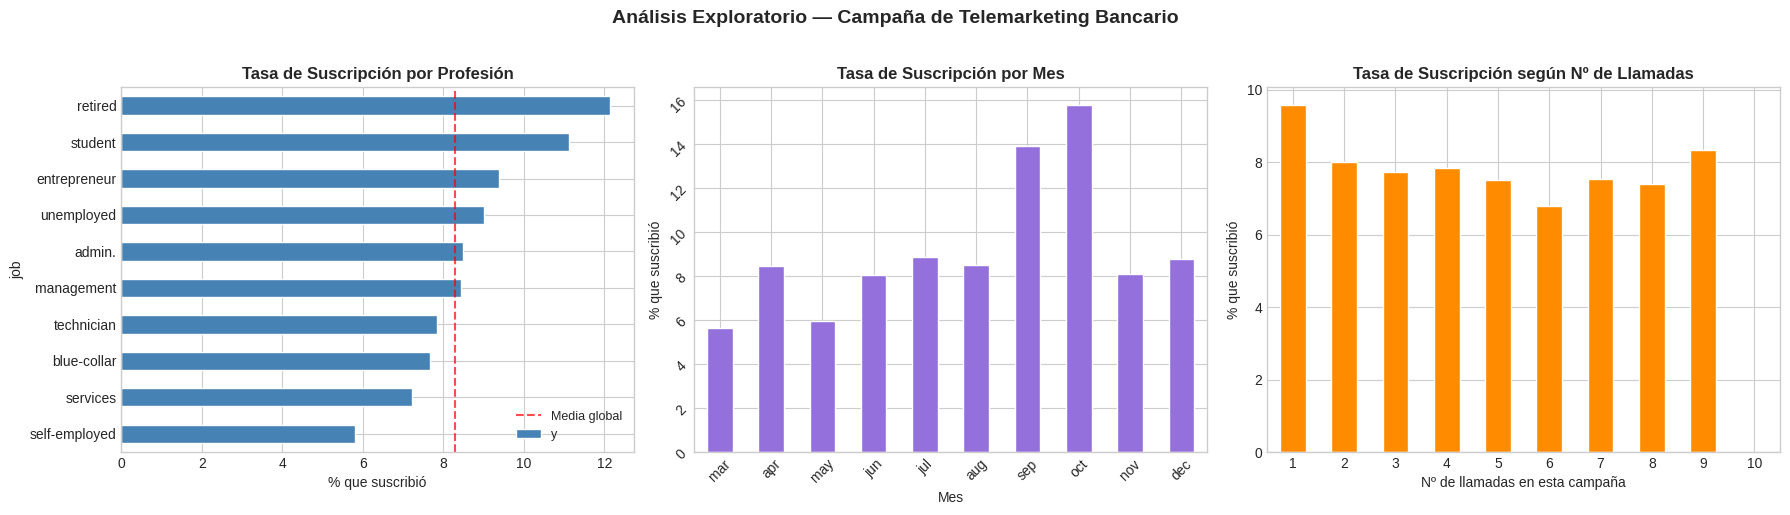

💡 Observaciones clave:
   → Estudiantes y jubilados: mayor tasa de conversión (más tiempo, menos activos financieramente)
   → Septiembre y octubre: los mejores meses para campañas
   → Más llamadas → menor tasa de conversión (cliente "quemado")


In [5]:
# ── Exploración visual ─────────────────────────────────────────────────────
# ¿Qué perfiles tienen más probabilidad de suscribir?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Tasa de suscripción por profesión
tasa_job = (df.groupby('job')['y'].mean() * 100).sort_values()
tasa_job.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(porcentaje[1], color='red', linestyle='--', alpha=0.7, label='Media global')
axes[0].set_title('Tasa de Suscripción por Profesión', fontweight='bold')
axes[0].set_xlabel('% que suscribió')
axes[0].legend(fontsize=9)

# Gráfico 2: Tasa de suscripción por mes
orden_meses = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
tasa_mes = (df.groupby('month')['y'].mean() * 100).reindex(
    [m for m in orden_meses if m in df['month'].unique()])
tasa_mes.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Tasa de Suscripción por Mes', fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('% que suscribió')
axes[1].tick_params(rotation=45)

# Gráfico 3: Número de llamadas vs tasa de suscripción
tasa_camp = (df.groupby('campaign')['y'].mean() * 100).head(10)
tasa_camp.plot(kind='bar', ax=axes[2], color='darkorange', edgecolor='white')
axes[2].set_title('Tasa de Suscripción según Nº de Llamadas', fontweight='bold')
axes[2].set_xlabel('Nº de llamadas en esta campaña')
axes[2].set_ylabel('% que suscribió')
axes[2].tick_params(rotation=0)

plt.suptitle('Análisis Exploratorio — Campaña de Telemarketing Bancario',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Observaciones clave:')
print('   → Estudiantes y jubilados: mayor tasa de conversión (más tiempo, menos activos financieramente)')
print('   → Septiembre y octubre: los mejores meses para campañas')
print('   → Más llamadas → menor tasa de conversión (cliente "quemado")')

---
## 🔧 4. Preparación: Encoding de Variables Categóricas

Los algoritmos de ML trabajan con **números**. XGBoost (y en general todos los modelos basados en árboles) necesita que convirtamos el texto en enteros.

**Label Encoding:** asigna un número entero a cada categoría única:  
`'admin.' → 0`, `'blue-collar' → 1`, `'entrepreneur' → 2`, ...  

Funciona bien para árboles porque el algoritmo encuentra los splits óptimos independientemente del valor numérico asignado.

In [6]:
# ── Copia para no modificar el original ───────────────────────────────────
df_model = df.copy()

# ── Label Encoding para todas las columnas de texto ────────────────────────
le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])
    # .fit_transform = aprende las categorías (fit) y las convierte (transform)

print('🔄 Encoding completado. Ejemplo con la columna "job":')
print(f'   Antes:   {sorted(df["job"].unique())}')
print(f'   Después: {sorted(df_model["job"].unique())}  (números enteros)')
print()
print('📋 Vista del dataset procesado (todas las columnas son ahora numéricas):')
df_model.head(3)

🔄 Encoding completado. Ejemplo con la columna "job":
   Antes:   ['admin.', 'blue-collar', 'entrepreneur', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed']
   Después: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]  (números enteros)

📋 Vista del dataset procesado (todas las columnas son ahora numéricas):


,age,job,marital,education,default,housing,loan,contact,month,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,45,1,1,4,0,0,0,1,6,3,12,4,2,-1.8,93.991,-43.1,3.740,5099.1,0
1,38,0,1,1,0,0,2,1,0,2,999,0,1,-1.7,92.865,-39.2,2.826,5008.7,0
2,47,0,0,4,0,2,0,1,6,2,999,0,1,1.4,92.546,-41.2,4.631,4963.6,0


In [7]:
# ── Separamos features (X) del target (y) ─────────────────────────────────
X = df_model.drop(columns=['y'])
y_target = df_model['y']

# ── Train / Test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target   # Mantiene el mismo ratio desbalanceado en train y test
)

# Calculamos el ratio para scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
ratio_desbalance = n_neg / n_pos

print('✂️  División de datos:')
print(f'   🔵 Entrenamiento: {X_train.shape[0]:,} contactos')
print(f'   🔴 Test:          {X_test.shape[0]:,}  contactos')
print()
print(f'⚖️  Ratio de desbalance (neg/pos): {ratio_desbalance:.1f}')
print(f'   Hay {ratio_desbalance:.0f} registros "no" por cada 1 "sí"')
print(f'   Pasaremos este valor a scale_pos_weight para compensar el desbalance')

✂️  División de datos:
   🔵 Entrenamiento: 8,000 contactos
   🔴 Test:          2,000  contactos

⚖️  Ratio de desbalance (neg/pos): 11.0
   Hay 11 registros "no" por cada 1 "sí"
   Pasaremos este valor a scale_pos_weight para compensar el desbalance


---
## 🔄 5. Random Forest vs XGBoost — ¿Cuál es la Diferencia Clave?

Antes de entrenar, entendamos conceptualmente qué hace diferente XGBoost:

### Random Forest → BAGGING (paralelo)
```
 Datos ──▶ Árbol 1 ──▶ Predicción 1 ─┐
      ├──▶ Árbol 2 ──▶ Predicción 2 ─┼──▶ VOTACIÓN ──▶ Resultado
      └──▶ Árbol N ──▶ Predicción N ─┘
      (todos ven los datos al mismo tiempo, en paralelo)
```

### XGBoost → BOOSTING (secuencial)
```
 Datos ──▶ Árbol 1 ──▶ Errores del Árbol 1
                ↓
           Árbol 2 aprende esos errores ──▶ Errores del Árbol 2
                ↓
           Árbol 3 aprende esos errores ──▶ Errores del Árbol 3
                ↓  (cada árbol corrige al anterior)
           SUMA PONDERADA de todos ──▶ Resultado
```

**Analogía:** Es como corregir un examen en equipo.
- **Random Forest** = 100 profesores corrigen de forma independiente y se promedia la nota.
- **XGBoost** = el primer profesor corrige, el segundo revisa sus errores, el tercero revisa los del segundo... hasta que no queda nada por corregir.

**Consecuencia práctica:**
- RF → cada árbol es *grande* (aprende todo lo que puede de los datos)
- XGBoost → cada árbol es *pequeño y enfocado* (solo corrige los errores residuales)

---
## 🚀 6. Entrenamiento del Modelo XGBoost

In [8]:
# ── Creamos el modelo XGBoost ──────────────────────────────────────────────
#
# Parámetros clave (los más importantes para entender):
#
# n_estimators=300       → máximo de rondas de boosting (árboles secuenciales)
#                          Con early_stopping no llegará necesariamente a 300
#
# learning_rate=0.1      → cuánto "aprende" cada árbol (también llamado eta)
#                          0.1 es el punto de partida estándar
#                          Si bajas el learning_rate, sube n_estimators
#
# max_depth=4            → profundidad máxima de cada árbol individual
#                          En XGBoost los árboles son MÁS PEQUEÑOS que en RF
#                          (3-6 es lo habitual; en RF se usa 5-10)
#
# scale_pos_weight       → peso extra para la clase minoritaria (los que SÍ suscriben)
#                          Equivalente al class_weight='balanced' de RandomForest
#                          Valor óptimo = ratio negativos/positivos en el training
#
# early_stopping_rounds=20 → para el entrenamiento si la métrica no mejora en 20 rondas
#                             Evita sobreajuste y ahorra tiempo de cómputo
#
# eval_metric='logloss'  → métrica interna para monitorizar el entrenamiento
#                          logloss es la estándar para clasificación binaria

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=ratio_desbalance,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

print('⚡ Modelo XGBoost configurado:')
print(f'   - Rondas máximas:     {xgb_model.n_estimators}')
print(f'   - Learning rate:      {xgb_model.learning_rate}')
print(f'   - Profundidad máxima: {xgb_model.max_depth}')
print(f'   - scale_pos_weight:   {ratio_desbalance:.1f}  ({ratio_desbalance:.0f} negativos por cada positivo)')
print(f'   - Early stopping:     {xgb_model.early_stopping_rounds} rondas sin mejora')

⚡ Modelo XGBoost configurado:
   - Rondas máximas:     300
   - Learning rate:      0.1
   - Profundidad máxima: 4
   - scale_pos_weight:   11.0  (11 negativos por cada positivo)
   - Early stopping:     20 rondas sin mejora


In [9]:
# ── Entrenamos el modelo ───────────────────────────────────────────────────
# eval_set = datos sobre los que monitorizar la métrica durante el entrenamiento
# Pasamos tanto train como test para poder visualizar ambas curvas después

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print('✅ Entrenamiento completado')
print(f'   - Rondas ejecutadas:          {xgb_model.best_iteration + 1}')
print(f'   - Mejor ronda (best_iteration): #{xgb_model.best_iteration + 1}')
print(f'   - Early stopping ahorró:        {300 - (xgb_model.best_iteration + 1)} rondas innecesarias')

✅ Entrenamiento completado
   - Rondas ejecutadas:          300
   - Mejor ronda (best_iteration): #300
   - Early stopping ahorró:        0 rondas innecesarias


---
## 🛑 7. Early Stopping — Parar en el Momento Justo

El Early Stopping es una de las funcionalidades más potentes de XGBoost: **el modelo para de entrenar automáticamente cuando deja de mejorar**.

Resuelve dos problemas a la vez:
- **Sobreajuste:** el modelo deja de memorizar el training cuando empieza a degradarse en validación.
- **Eficiencia:** no entrenamos rondas que ya no aportan nada.

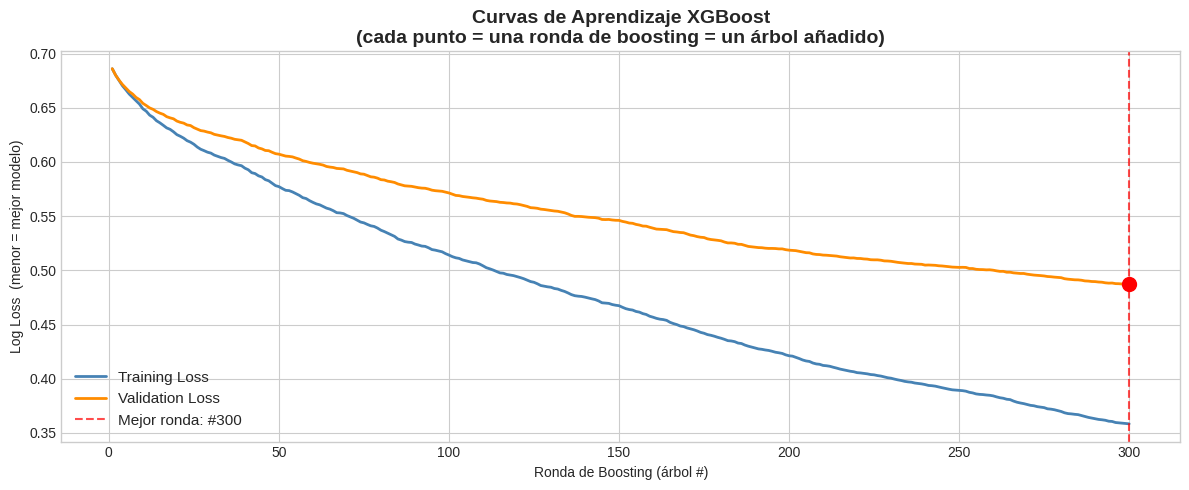

📊 Lectura de las curvas:
   → Ambas curvas bajan al principio: el modelo está aprendiendo ✅
   → En algún punto la validación toca su mínimo y deja de mejorar
   → Si training sigue bajando pero validación sube: SOBREAJUSTE ⚠️
   → Early stopping paró en la ronda #300 al detectar que no mejoraba


In [10]:
# ── Visualizamos las curvas de aprendizaje ─────────────────────────────────
# evals_result_() devuelve el logloss en cada ronda para cada eval_set
# validation_0 = primer elemento del eval_set → X_train (training loss)
# validation_1 = segundo elemento del eval_set → X_test  (validation loss)

results  = xgb_model.evals_result()
train_ll = results['validation_0']['logloss']
val_ll   = results['validation_1']['logloss']
epochs   = range(1, len(train_ll) + 1)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(epochs, train_ll, label='Training Loss',   color='steelblue',  linewidth=2)
ax.plot(epochs, val_ll,   label='Validation Loss', color='darkorange', linewidth=2)

# Marcamos la mejor ronda (mínimo de la curva de validación)
mejor_ronda = xgb_model.best_iteration + 1
ax.axvline(mejor_ronda, color='red', linestyle='--', alpha=0.7, label=f'Mejor ronda: #{mejor_ronda}')
ax.scatter(mejor_ronda, val_ll[mejor_ronda - 1], color='red', s=100, zorder=5)

ax.set_title('Curvas de Aprendizaje XGBoost\n(cada punto = una ronda de boosting = un árbol añadido)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ronda de Boosting (árbol #)')
ax.set_ylabel('Log Loss  (menor = mejor modelo)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('📊 Lectura de las curvas:')
print('   → Ambas curvas bajan al principio: el modelo está aprendiendo ✅')
print('   → En algún punto la validación toca su mínimo y deja de mejorar')
print('   → Si training sigue bajando pero validación sube: SOBREAJUSTE ⚠️')
print(f'   → Early stopping paró en la ronda #{mejor_ronda} al detectar que no mejoraba')

---
## 📊 8. Evaluación: Accuracy, AUC-ROC, Matriz de Confusión

Para datasets **muy desbalanceados** como este (92%/8%), el accuracy puede ser engañoso.  
Introducimos una nueva métrica: el **AUC-ROC**.

In [11]:
# ── Predicciones ──────────────────────────────────────────────────────────
y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]   # Probabilidad de suscribir (clase 1)

# ── Métricas ───────────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('📈 Métricas del modelo XGBoost sobre el conjunto de test:')
print(f'   Accuracy:  {acc*100:.1f}%')
print(f'   AUC-ROC:   {auc:.3f}')
print()
print('⚠️  Por qué no basta con el Accuracy aquí:')
print('   Si el modelo dijera SIEMPRE "no suscribirá" → tendría el 92% de accuracy.')
print('   Pero ese modelo sería completamente inútil para el negocio.')
print()
print('📐 Interpretación del AUC-ROC:')
print('   0.50 = modelo aleatorio (inútil como tirar una moneda)')
print('   0.70 = aceptable para muchos casos de negocio')
print('   0.80 = bueno ← objetivo habitual en proyectos reales')
print('   0.90 = excelente (suele indicar un problema bien estructurado)')
print('   1.00 = perfecto (sospechoso: probablemente hay data leakage)')

📈 Métricas del modelo XGBoost sobre el conjunto de test:
   Accuracy:  78.2%
   AUC-ROC:   0.553

⚠️  Por qué no basta con el Accuracy aquí:
   Si el modelo dijera SIEMPRE "no suscribirá" → tendría el 92% de accuracy.
   Pero ese modelo sería completamente inútil para el negocio.

📐 Interpretación del AUC-ROC:
   0.50 = modelo aleatorio (inútil como tirar una moneda)
   0.70 = aceptable para muchos casos de negocio
   0.80 = bueno ← objetivo habitual en proyectos reales
   0.90 = excelente (suele indicar un problema bien estructurado)
   1.00 = perfecto (sospechoso: probablemente hay data leakage)


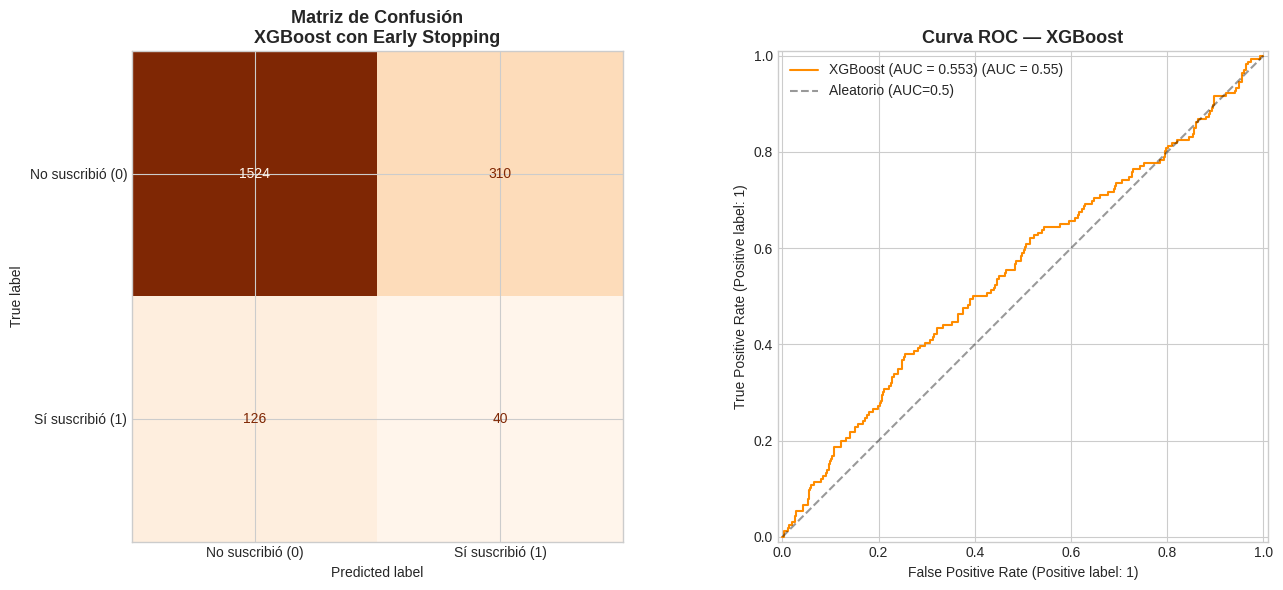

📊 Desglose de resultados:
   ✅ TN = 1,524  → predijo NO  y era NO
   ✅ TP = 40  → predijo SÍ  y era SÍ
   ❌ FP = 310  → predijo SÍ  y era NO  (llamada innecesaria)
   ❌ FN = 126  → predijo NO  y era SÍ  (cliente perdido)


In [12]:
# ── Visualización: Matriz de Confusión + Curva ROC ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Matriz de confusión ────────────────────────────────────────────────────
#                   PREDICCIÓN
#              No(0)     │   Sí(1)
#         ───────────────────────────
#  REAL    No(0)   TN    │    FP
#         ───────────────────────────
#          Sí(1)   FN    │    TP
#
# FP = Falso Positivo: predijimos que suscribiría y no lo hizo → llamada innecesaria (coste)
# FN = Falso Negativo: predijimos que no y sí lo habría hecho → cliente potencial perdido

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No suscribió (0)', 'Sí suscribió (1)']
).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Matriz de Confusión\nXGBoost con Early Stopping', fontsize=13, fontweight='bold')

# ── Curva ROC ─────────────────────────────────────────────────────────────
# Muestra el trade-off entre capturar clientes buenos (TPR) vs molestar a los malos (FPR)
# Cuanto más arriba-izquierda esté la curva, mejor el modelo
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name=f'XGBoost (AUC = {auc:.3f})',
    ax=axes[1], color='darkorange'
)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio (AUC=0.5)')
axes[1].set_title('Curva ROC — XGBoost', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print('📊 Desglose de resultados:')
print(f'   ✅ TN = {tn:,}  → predijo NO  y era NO')
print(f'   ✅ TP = {tp:,}  → predijo SÍ  y era SÍ')
print(f'   ❌ FP = {fp:,}  → predijo SÍ  y era NO  (llamada innecesaria)')
print(f'   ❌ FN = {fn:,}  → predijo NO  y era SÍ  (cliente perdido)')

In [13]:
# ── Classification Report ──────────────────────────────────────────────────
#
# PRECISION clase 1 = De todos los que el modelo dice "SÍ suscribirá",
#                      ¿qué % realmente lo hace?
#                      → Queremos esto alto para no desperdiciar llamadas
#
# RECALL    clase 1 = De todos los que HABRÍAN suscrito,
#                      ¿a qué % detectamos?
#                      → Queremos esto alto para no perder clientes
#
# F1-SCORE           = Media armónica Precision + Recall
#                      → La mejor métrica resumen con clases desbalanceadas

print('📋 Classification Report completo:')
print('='*60)
print(classification_report(
    y_test, y_pred,
    target_names=['No suscribió (0)', 'Sí suscribió (1)']
))
print()
print('💼 Cómo leerlo para el equipo comercial del banco:')
print('   → Precision alta en clase 1: cuando llamamos, acertamos,no es el caso')
print('   → Recall alto en clase 1:    no nos perdemos clientes potenciales, no es el caso')
print('   → El F1-Score pondera ambos: es la métrica de referencia en este caso')

📋 Classification Report completo:
                  precision    recall  f1-score   support

No suscribió (0)       0.92      0.83      0.87      1834
Sí suscribió (1)       0.11      0.24      0.16       166

        accuracy                           0.78      2000
       macro avg       0.52      0.54      0.51      2000
    weighted avg       0.86      0.78      0.82      2000


💼 Cómo leerlo para el equipo comercial del banco:
   → Precision alta en clase 1: cuando llamamos, acertamos
   → Recall alto en clase 1:    no nos perdemos clientes potenciales
   → El F1-Score pondera ambos: es la métrica de referencia en este caso


---
## 🔍 9. Feature Importance y Explicabilidad

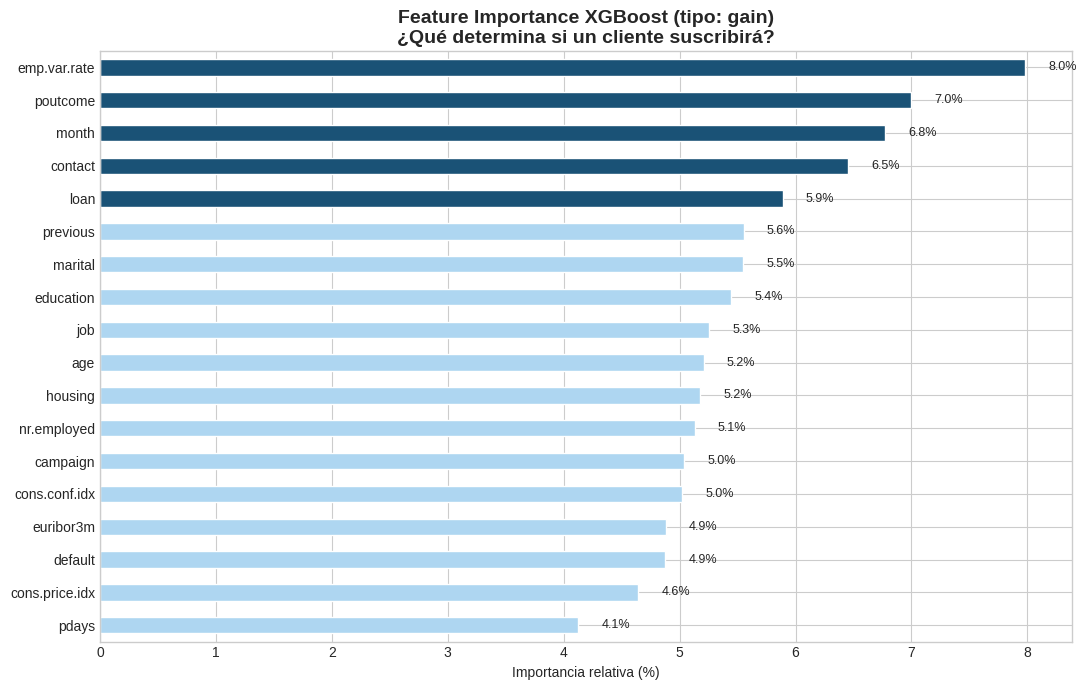

🏆 Top 5 variables:
   1. emp.var.rate         8.0%
   2. poutcome             7.0%
   3. month                6.8%
   4. contact              6.5%
   5. loan                 5.9%

💡 Cómo usarlo en negocio:
   → Las variables top son las que más deben considerar los comerciales
   → Permiten segmentar la cartera y priorizar qué clientes contactar primero
   → Si "poutcome" (éxito previo) es top, tiene sentido recontactar campañas anteriores


In [14]:
# ── Importancia por 'gain' ─────────────────────────────────────────────────
# XGBoost ofrece 3 tipos de importancia:
#  'weight' → cuántas veces se usa la variable para hacer splits
#  'gain'   → cuánto mejora el modelo en cada split (el más interpretable)
#  'cover'  → cuántos ejemplos afecta cada split
# En la práctica, 'gain' es el más informativo para negocio

importances = pd.Series(
    xgb_model.get_booster().get_score(importance_type='gain'),
    name='Importancia (gain)'
).sort_values(ascending=True)

importances = importances / importances.sum() * 100   # Normalizar a %

# ── Visualización ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#1A5276' if i >= len(importances) - 5 else '#AED6F1'
          for i in range(len(importances))]

importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance XGBoost (tipo: gain)\n¿Qué determina si un cliente suscribirá?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia relativa (%)')

for i, val in enumerate(importances.values):
    ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('🏆 Top 5 variables:')
for i, (feat, imp) in enumerate(importances.sort_values(ascending=False).head(5).items(), 1):
    print(f'   {i}. {feat:<20} {imp:.1f}%')
print()
print('💡 Cómo usarlo en negocio:')
print('   → Las variables top son las que más deben considerar los comerciales')
print('   → Permiten segmentar la cartera y priorizar qué clientes contactar primero')
print('   → Si "poutcome" (éxito previo) es top, tiene sentido recontactar campañas anteriores')

1. emp.var.rate — 8% (tasa de variación del empleo)

2. poutcome — 7% (resultado de la campaña anterior)
Si ese mismo cliente ya suscribió un depósito en una campaña anterior

3. month — 6.8% (mes del año en que se realiza la llamada)
No todos los meses son igual de buenos para vender depósitos.  

4. contact — 6.5% (canal de contacto: móvil o teléfono fijo)
Los clientes contactados por móvil convierten significativamente mejor que los de teléfono fijo.

5. loan — 5.9% (si el cliente tiene un préstamo personal activo)